# Build the empirical average region profile

This notebook extracts radial Halpha+OIII amplitude profiles from the final catalog regions, using rays from each central peak out to that region's final boundary. Each ray is background-subtracted, normalized by the central peak contrast, scaled by its measured half-light radius, and then combined into a single average profile for custom peak-completeness injections.

In [50]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == "peak_completeness":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import peak_completeness.custom_profiles as custom_profiles
custom_profiles = importlib.reload(custom_profiles)

DEFAULT_PROFILE_DIR = custom_profiles.DEFAULT_PROFILE_DIR
ProfileExtractionConfig = custom_profiles.ProfileExtractionConfig
build_average_region_profile = custom_profiles.build_average_region_profile
fit_average_profile_models = custom_profiles.fit_average_profile_models
save_average_region_profile = custom_profiles.save_average_region_profile

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300, "figure.figsize": (8, 6)})

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

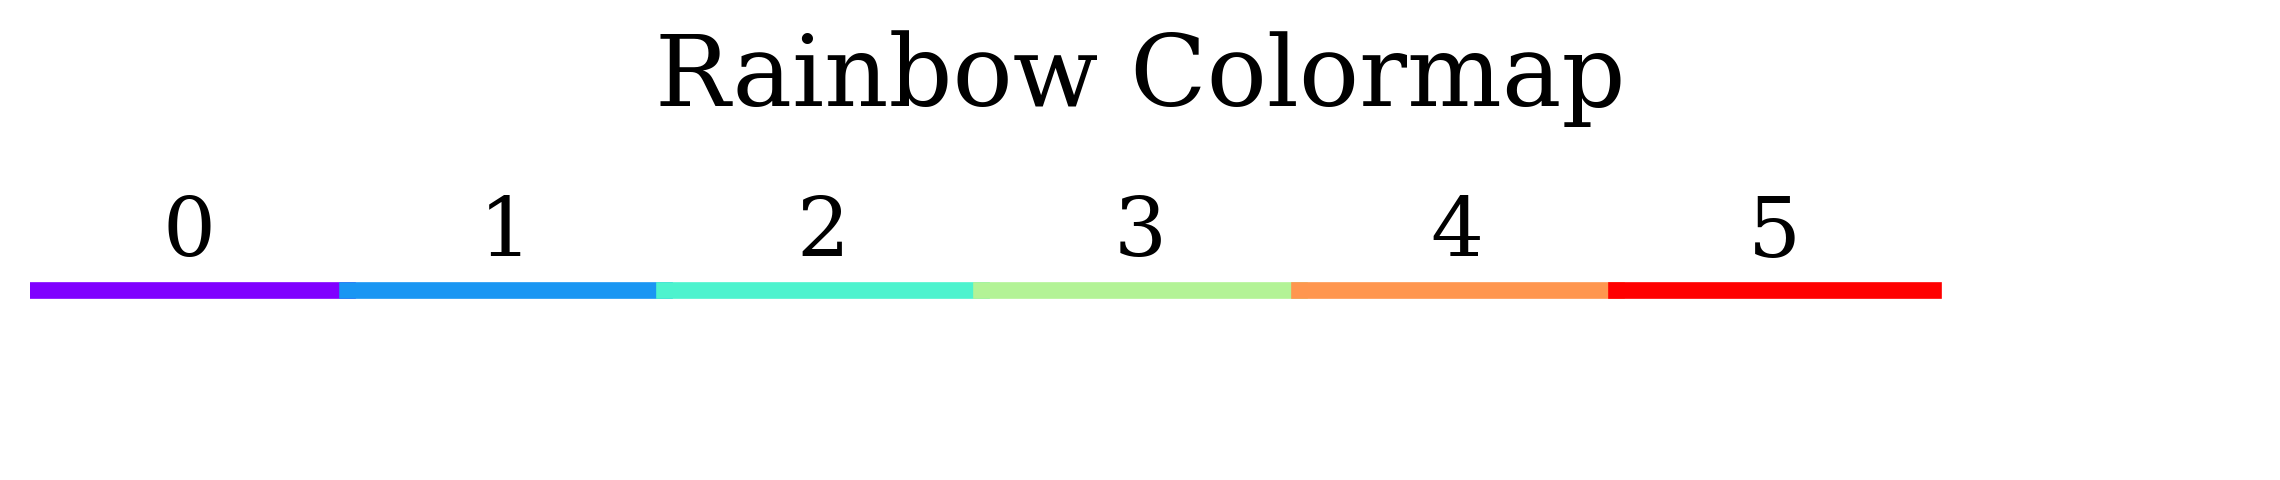

In [72]:
#make a list of 15 evenly spaced colours from the rainbow cmap to be used in all plots
cmap = plt.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 6)]
#show the colours
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.plot([i, i + 1], [0, 0], color=color, lw=4)
#label each colour with its index
for i in range(len(colors)):
    plt.text(i + 0.5, 0.1, str(i), ha='center', va='bottom')
plt.xlim(0, len(colors) + 1)
plt.ylim(-1, 1)
plt.axis('off')
plt.title('Rainbow Colormap')
plt.tight_layout()

In [ ]:
# DEFAULT_PROFILE_DIR

## Extract profiles

The main knobs are the number of azimuthal rays, the radial sampling step, and the maximum normalized radius kept in the final profile. The normalization radius is measured from each region profile itself, so the final coordinate is `r / r50`.

In [ ]:
config = ProfileExtractionConfig(
    n_theta=72,
    dr_px=0.5,
    r_grid_max=4.0,
    n_r_grid=161,
    min_boundary_pixels=20,
    smooth_sigma_bins=1.0,
)

average, metrics, all_profiles = build_average_region_profile(config)

In [45]:
fits = fit_average_profile_models(average)

DEFAULT_PROFILE_DIR.mkdir(parents=True, exist_ok=True)
save_average_region_profile(average, metrics, all_profiles, output_dir=DEFAULT_PROFILE_DIR)
fits.to_csv(DEFAULT_PROFILE_DIR / "average_profile_model_fits.csv", index=False)

print(f"Saved average profile to {DEFAULT_PROFILE_DIR / 'average_region_profile.csv'}")
print(f"Extracted {metrics['region_id'].nunique()} region profiles")
display(fits)

Saved average profile to /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_completeness/average_region_profile/average_region_profile.csv
Extracted 5060 region profiles


,model,rss,aic,p0,p1,p2,p3,p4,amp_narrow,sigma_narrow,amp_broad,sigma_broad,floor,amp,core_radius_r50,exp_index,wing_index
4,core_power_exp,0.007311,-1599.966146,0.991995,1.710960,3.401914e+00,1.014335,1.250732e-17,NaN,NaN,NaN,NaN,1.250732e-17,0.991995,1.71096,3.401914,1.014335
2,pseudo_voigt,0.048812,-1294.290353,0.976733,0.968520,1.478581e-01,0.103073,4.940656e-324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,gaussian,0.072215,-1235.231526,0.910834,0.948428,4.940656e-324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,narrow_broad_double_gaussian,0.125131,-1142.727538,0.768589,0.863159,1.500000e-01,1.500000,9.541816e-19,0.768589,0.863159,0.15,1.5,9.541816e-19,NaN,NaN,NaN,NaN
1,exponential,0.785928,-850.889362,1.153010,1.012959,6.787103e-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Average profile and analytic fits

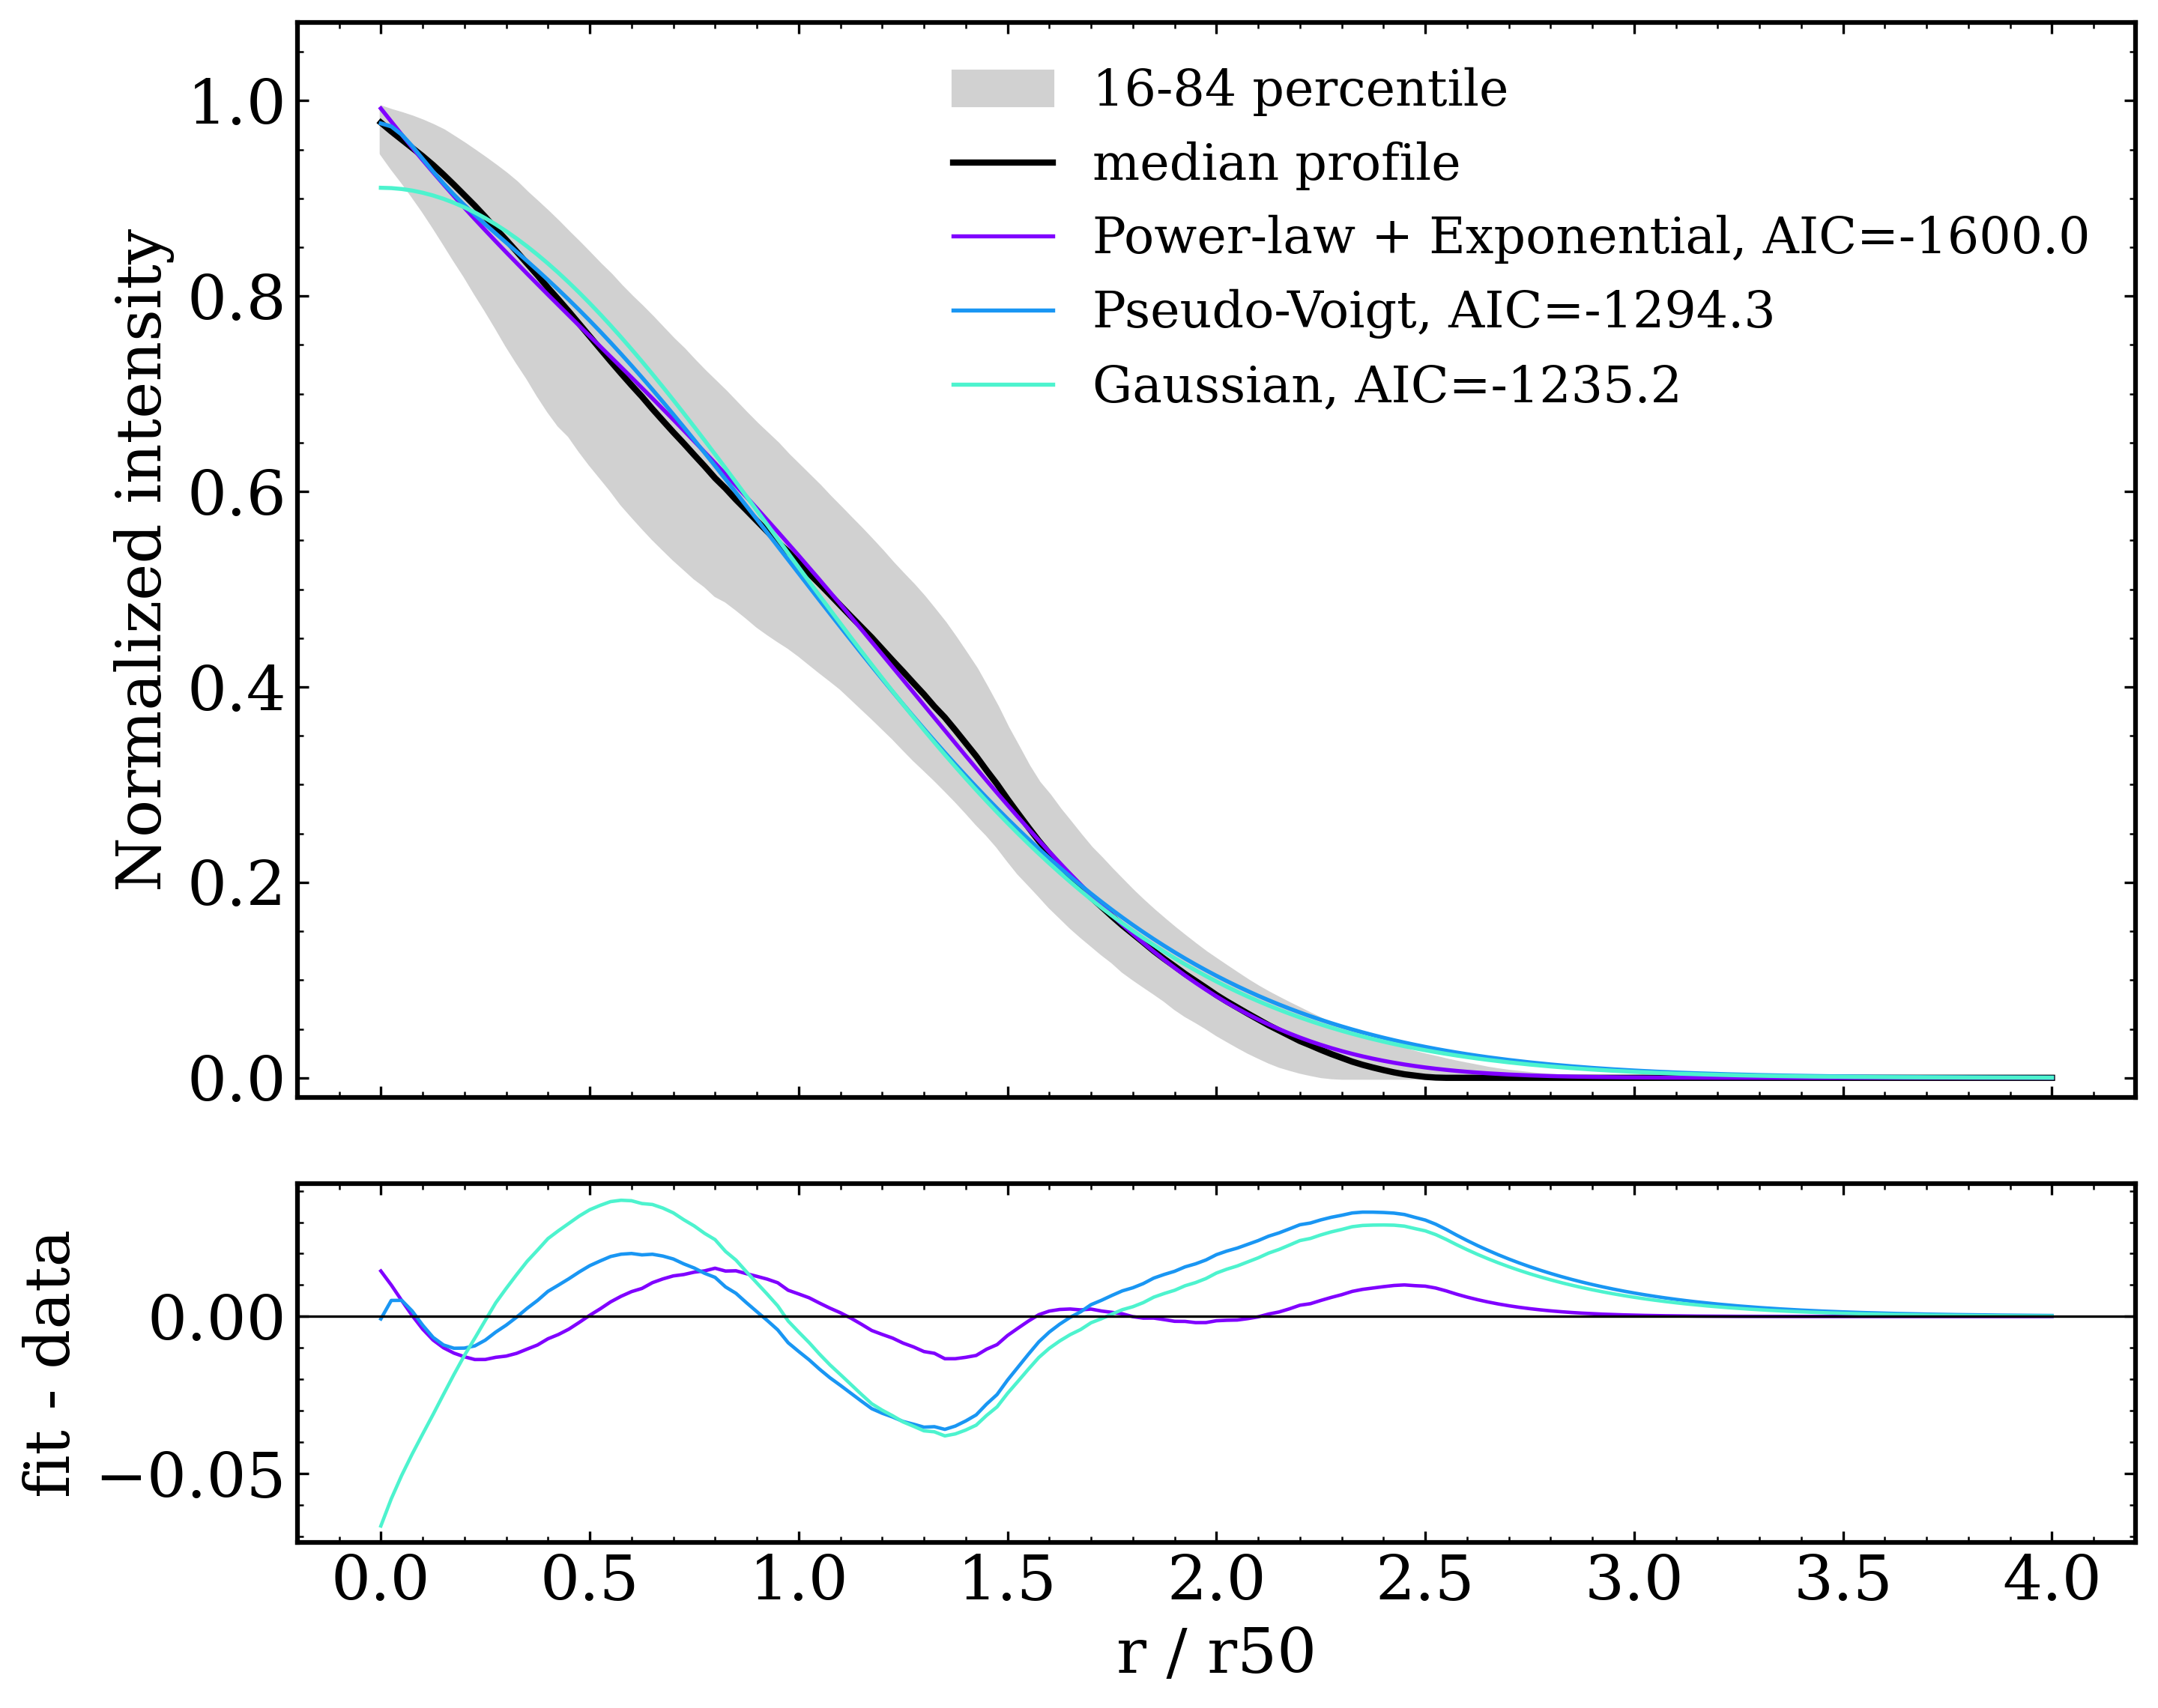

In [77]:
model_functions = {
    "gaussian": custom_profiles.gaussian_model,
    # "exponential": custom_profiles.exponential_model,
    "pseudo_voigt": custom_profiles.pseudo_voigt_model,
    # "double_gaussian": custom_profiles.double_gaussian_model,
    # "narrow_broad_double_gaussian": custom_profiles.double_gaussian_model,
    "core_power_exp": custom_profiles.core_power_exp_model,
}

names = {"gaussian": "Gaussian", "pseudo_voigt": "Pseudo-Voigt", "core_power_exp": "Power-law + Exponential"}

fig, (ax, ax_resid) = plt.subplots(
    2,
    1,
    figsize=(10.0, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)
ax.fill_between(
    average["r_over_r50"],
    average["p16_normalized_intensity"],
    average["p84_normalized_intensity"],
    color="0.82",
    label="16-84 percentile",
)


ax.plot(average["r_over_r50"], average["median_normalized_intensity"], color="black", lw=2, label="median profile")

r = average["r_over_r50"].to_numpy(float)
y_data = average["median_normalized_intensity"].to_numpy(float)
for _, fit in fits.dropna(subset=["aic"]).iterrows():
    name = fit["model"]
    if name not in model_functions:
        continue
    params = [fit[f"p{i}"] for i in range(sum(col.startswith("p") for col in fit.index)) if pd.notna(fit.get(f"p{i}"))]
    y_fit = model_functions[name](r, *params)
    ax.plot(r, y_fit, lw=1.3, label=f"{names[fit['model']]}, AIC={fit['aic']:.1f}", color = colors[fits.index.get_loc(fit.name) % len(colors)])
    ax_resid.plot(r, y_fit - y_data, lw=1.1, label=name, color = colors[fits.index.get_loc(fit.name) % len(colors)])

ax.set(ylabel="Normalized intensity", ylim=(-0.02, 1.08))
ax.legend(fontsize=16, loc="upper right", frameon=False)
ax_resid.axhline(0.0, color="black", lw=0.8)
ax_resid.set(xlabel="r / r50", ylabel="fit - data")
fig.tight_layout()
fig.savefig(DEFAULT_PROFILE_DIR / "average_profile_with_model_fits.png")

In [ ]:
# len(colors)

15

## Steep, intermediate, and flat profile groups

This first grouping uses the median profile slope between `1 r50` and `2 r50`. More negative slopes are steeper; slopes closer to zero are flatter.

,n_regions,median_outer_slope
profile_shape_group,,
flat,1687,-0.324268
intermediate,1686,-0.414749
steep,1687,-0.499853


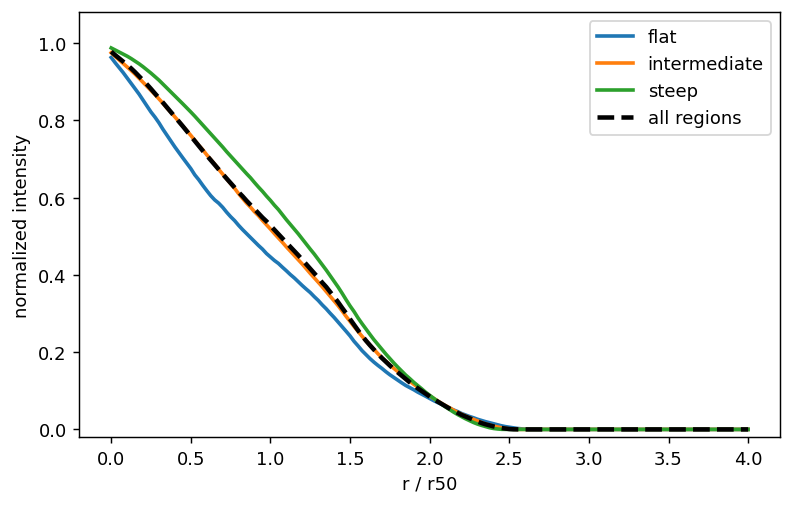

In [47]:
metrics = metrics.copy()
q1, q2 = metrics["outer_slope"].quantile([1 / 3, 2 / 3])
metrics["profile_shape_group"] = np.select(
    [metrics["outer_slope"] <= q1, metrics["outer_slope"] >= q2],
    ["steep", "flat"],
    default="intermediate",
)
metrics.to_csv(DEFAULT_PROFILE_DIR / "region_profile_metrics.csv", index=False)

grouped_profiles = (
    all_profiles.merge(metrics[["field", "region_id", "profile_shape_group"]], on=["field", "region_id"], how="inner")
    .groupby(["profile_shape_group", "r_over_r50"], observed=False, as_index=False)
    .agg(median_normalized_intensity=("normalized_intensity", "median"), n_regions=("region_id", "nunique"))
)
grouped_profiles.to_csv(DEFAULT_PROFILE_DIR / "average_profiles_by_shape_group.csv", index=False)

fig, ax = plt.subplots(figsize=(6.2, 4.0))
for group, data in grouped_profiles.groupby("profile_shape_group", observed=False):
    ax.plot(data["r_over_r50"], data["median_normalized_intensity"], lw=2, label=f"{group}")
ax.plot(average["r_over_r50"], average["median_normalized_intensity"], color="black", lw=2.5, ls="--", label="all regions")
ax.set(xlabel="r / r50", ylabel="normalized intensity", ylim=(-0.02, 1.08))
ax.legend()
fig.tight_layout()
fig.savefig(DEFAULT_PROFILE_DIR / "profile_shape_groups.png")

display(metrics.groupby("profile_shape_group", observed=False).agg(n_regions=("region_id", "count"), median_outer_slope=("outer_slope", "median")))

## Example steepest and flattest regions

,example_set,field,region_id,region_number,outer_slope,edge_radius_over_r50_median
0,steepest,SE,SE_0241,241,-0.906604,3.048905
1,steepest,SW,SW_0516,516,-0.767137,1.947707
2,steepest,F7,F7_0328,328,-0.766934,2.042231
3,steepest,SW,SW_0924,924,-0.747502,1.647239
4,steepest,SW,SW_0174,174,-0.729795,1.676552
5,steepest,NW,NW_0713,713,-0.725013,2.734743
6,flattest,F5,F5_0111,111,-0.028632,1.817327
7,flattest,F5,F5_0378,378,-0.078883,1.838677
8,flattest,F6,F6_0225,225,-0.079354,1.927818
9,flattest,F5,F5_0445,445,-0.086092,3.005831


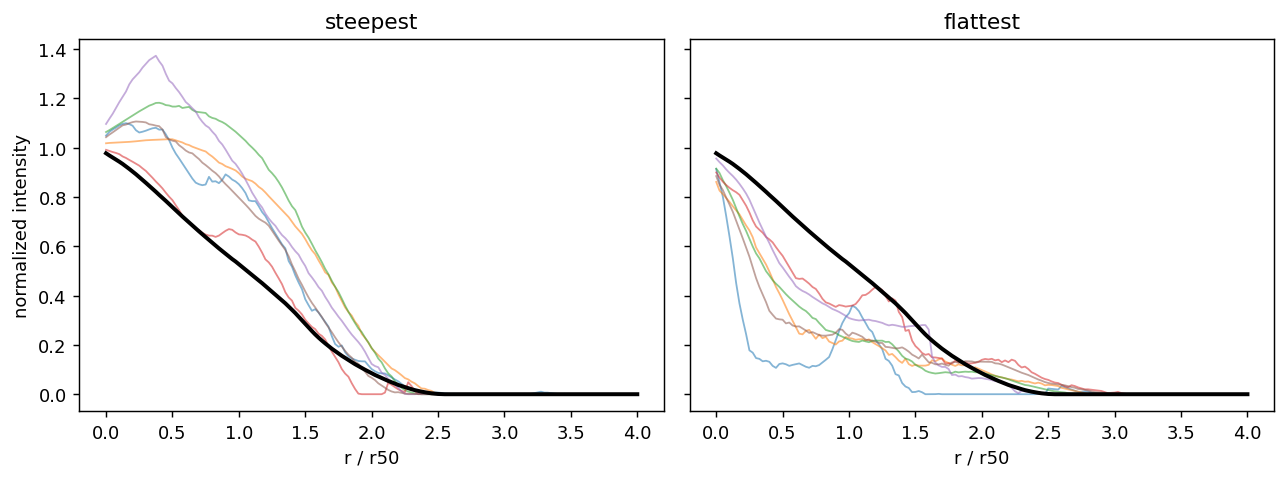

In [48]:
examples = pd.concat([
    metrics.nsmallest(6, "outer_slope").assign(example_set="steepest"),
    metrics.nlargest(6, "outer_slope").assign(example_set="flattest"),
], ignore_index=True)
examples.to_csv(DEFAULT_PROFILE_DIR / "steepest_flattest_profile_examples.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True, sharey=True)
for ax, example_set in zip(axes, ["steepest", "flattest"]):
    ids = examples.loc[examples["example_set"] == example_set, ["field", "region_id"]]
    subset = all_profiles.merge(ids, on=["field", "region_id"], how="inner")
    for (_, region_id), data in subset.groupby(["field", "region_id"]):
        ax.plot(data["r_over_r50"], data["normalized_intensity"], alpha=0.55, lw=1)
    ax.plot(average["r_over_r50"], average["median_normalized_intensity"], color="black", lw=2.2)
    ax.set_title(example_set)
    ax.set_xlabel("r / r50")
axes[0].set_ylabel("normalized intensity")
fig.tight_layout()
fig.savefig(DEFAULT_PROFILE_DIR / "steepest_flattest_profile_examples.png")
display(examples[["example_set", "field", "region_id", "region_number", "outer_slope", "edge_radius_over_r50_median"]])

## Use in peak completeness

After this notebook has written `average_region_profile.csv`, run custom-profile injections with:

```bash
python -m peak_completeness.run_peak_completeness --morphologies custom --output-dir peak_completeness/results_custom
```

To compare against Gaussians in the same run:

```bash
python -m peak_completeness.run_peak_completeness --morphologies gaussian custom --output-dir peak_completeness/results_gaussian_custom
```